# Feature Extraction - Figshare Dataset

**Objective:** Extract multi-domain features from windowed sensor data for FoG detection.

**Features extracted:**
- Time-domain: mean, std, skewness, kurtosis, RMS, median, IQR, cadence
- Frequency-domain: PSD peak, total energy, band powers, freezing index
- Wavelet: energy per level, entropy
- Nonlinear: sample entropy, fractal dimension

**Pipeline:**
1. Load windowed LOSO splits
2. Initialize the feature extractor
3. Process all folds: extract features directly from raw windows → save CSVs
4. Analyze extracted features with visualizations

In [15]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tqdm import tqdm

from features import FeatureExtractor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Windowed Data

In [ ]:
# Load binary LOSO splits
data_path = Path('../../outputs/datasets_csv/figshare_loso_windows_binary.pkl')
feature_output_dir = Path('../../outputs/figshare_features')

FIGSHARE_NOTEBOOK03_MODE = 'full_pickle'
TOTAL_TRAIN_WINDOWS = 0
TOTAL_TEST_WINDOWS = 0

try:
    with open(data_path, 'rb') as f:
        loso_splits = pickle.load(f)

    TOTAL_TRAIN_WINDOWS = sum(len(fold['y_train']) for fold in loso_splits)
    TOTAL_TEST_WINDOWS = sum(len(fold['y_test']) for fold in loso_splits)

    print(f"✅ Loaded {len(loso_splits)} LOSO folds from pickle")
    print(f"   Total train windows: {TOTAL_TRAIN_WINDOWS:,}")
    print(f"   Total test windows: {TOTAL_TEST_WINDOWS:,}")

except MemoryError:
    FIGSHARE_NOTEBOOK03_MODE = 'existing_feature_folds'
    available_fold_dirs = sorted(path for path in feature_output_dir.glob('fold_subj_*') if path.is_dir())

    if not available_fold_dirs:
        raise MemoryError(
            'figshare_loso_windows_binary.pkl does not fit in memory and no existing feature folds were found.'
        )

    loso_splits = [
        {'test_subject': fold_dir.name.replace('fold_subj_', '')}
        for fold_dir in available_fold_dirs
    ]

    for fold_dir in available_fold_dirs:
        y_train_path = fold_dir / 'y_train.csv'
        y_test_path = fold_dir / 'y_test.csv'
        if y_train_path.exists():
            TOTAL_TRAIN_WINDOWS += len(pd.read_csv(y_train_path))
        if y_test_path.exists():
            TOTAL_TEST_WINDOWS += len(pd.read_csv(y_test_path))

    print('⚠️ MemoryError while loading the full LOSO pickle.')
    print('   Falling back to existing feature-fold CSVs already saved on disk.')
    print(f"   Available feature folds: {len(loso_splits)}")
    print(f"   Total train windows (from CSVs): {TOTAL_TRAIN_WINDOWS:,}")
    print(f"   Total test windows (from CSVs): {TOTAL_TEST_WINDOWS:,}")
    print('   Raw-window re-extraction is skipped in this mode unless notebook 02 is regenerated in a lighter format.')

MemoryError: 

## 2. Initialize Feature Extractor

Audit-aligned setting: features are extracted directly from raw windowed signals without outlier cleaning or aggressive interpolation.

In [ ]:
print("✅ Raw-window feature extraction enabled")
print("   Outlier cleaning: disabled")
print("   Missing-value interpolation: disabled")
print("   Windowed signals are preserved as generated in notebook 02")

✅ Raw-window feature extraction enabled
   Outlier cleaning: disabled
   Missing-value interpolation: disabled
   Windowed signals are preserved as generated in notebook 02


In [ ]:
# Feature extractor
SAMPLING_RATE = 128  # Hz for Figshare

extractor = FeatureExtractor(
    sampling_rate=SAMPLING_RATE,
    extract_time=True,
    extract_frequency=True,
    extract_wavelet=True,
    extract_nonlinear=True  # Enabled for robust cross-dataset pipeline
)

# Channel groups for per-sensor magnitude computation
# Figshare: 6 channels — acc (0-2) + gyr (3-5) on lower back
CHANNEL_GROUPS = {
    'acc_lower_back': [0, 1, 2],
    'gyr_lower_back': [3, 4, 5],
}

print("✅ Feature extractor initialized")
print(f"   Sampling rate: {SAMPLING_RATE} Hz")
print(f"   Time-domain: ✅")
print(f"   Frequency-domain: ✅")
print(f"   Wavelet: ✅")
print(f"   Nonlinear: ✅")
print(f"   Channel groups: {list(CHANNEL_GROUPS.keys())}")

✅ Feature extractor initialized
   Sampling rate: 128 Hz
   Time-domain: ✅
   Frequency-domain: ✅
   Wavelet: ✅
   Nonlinear: ✅
   Channel groups: ['acc_lower_back', 'gyr_lower_back']


## 3. Process All LOSO Folds

Extract features from all folds and save to CSV files.

In [ ]:
# Output directory
feature_output_dir = Path('../../outputs/figshare_features')
feature_output_dir.mkdir(parents=True, exist_ok=True)

expected_subjects = [fold['test_subject'] for fold in loso_splits]
expected_dirs = {f'fold_subj_{subject}' for subject in expected_subjects}
existing_dirs = {path.name for path in feature_output_dir.glob('fold_subj_*') if path.is_dir()}
stale_dirs = sorted(existing_dirs - expected_dirs)
required_files = [
    'X_train_features.csv',
    'y_train.csv',
    'subjects_train.csv',
    'X_test_features.csv',
    'y_test.csv',
]

print('🚀 Processing all LOSO folds...')
print('=' * 70)
print(f'Expected LOSO folds from notebook 02: {len(expected_subjects)}')
print(f'Mode: {FIGSHARE_NOTEBOOK03_MODE}')
if stale_dirs:
    print(f'⚠️ Stale feature directories detected: {len(stale_dirs)}')
    for name in stale_dirs[:10]:
        print(f'   - {name}')
    if len(stale_dirs) > 10:
        print(f'   ... and {len(stale_dirs) - 10} more')

processed_subjects = []

if FIGSHARE_NOTEBOOK03_MODE == 'full_pickle':
    for fold in tqdm(loso_splits, desc='Processing folds'):
        test_subject = fold['test_subject']

        # 1. Extract features directly from raw windows
        X_train_features = extractor.extract_from_windows(
            fold['X_train'], n_jobs=-1, verbose=True, channel_groups=CHANNEL_GROUPS)
        X_test_features = extractor.extract_from_windows(
            fold['X_test'], n_jobs=-1, verbose=True, channel_groups=CHANNEL_GROUPS)

        # 2. Save to CSV
        fold_dir = feature_output_dir / f'fold_subj_{test_subject}'
        fold_dir.mkdir(parents=True, exist_ok=True)

        X_train_features.to_csv(fold_dir / 'X_train_features.csv', index=False)
        pd.Series(fold['y_train'], name='label').to_csv(fold_dir / 'y_train.csv', index=False)
        pd.Series(fold['subjects_train'], name='subject').to_csv(fold_dir / 'subjects_train.csv', index=False)
        X_test_features.to_csv(fold_dir / 'X_test_features.csv', index=False)
        pd.Series(fold['y_test'], name='label').to_csv(fold_dir / 'y_test.csv', index=False)

        processed_subjects.append(test_subject)
else:
    print('Skipping raw-window extraction to avoid the pickle MemoryError.')
    print('Using existing per-fold feature CSVs already stored in outputs/figshare_features.')
    processed_subjects = expected_subjects.copy()

missing_outputs = []
for subject in expected_subjects:
    fold_dir = feature_output_dir / f'fold_subj_{subject}'
    for filename in required_files:
        if not (fold_dir / filename).exists():
            missing_outputs.append(f'{fold_dir.name}/{filename}')

print('\n' + '=' * 70)
print(f'✅ Feature extraction complete for {len(processed_subjects)} folds')
print(f'📁 Output directory: {feature_output_dir}')
if missing_outputs:
    print(f'❌ Missing output files detected: {len(missing_outputs)}')
    for path in missing_outputs[:10]:
        print(f'   - {path}')
    if len(missing_outputs) > 10:
        print(f'   ... and {len(missing_outputs) - 10} more')
    raise RuntimeError('Figshare feature extraction is incomplete. Re-run notebook 03 to regenerate all expected folds.')
else:
    print('✅ Output validation passed: all expected fold files are present')
print('=' * 70)

🚀 Processing all LOSO folds...
Expected LOSO folds from notebook 02: 35


Processing folds:   0%|          | 0/35 [00:00<?, ?it/s][Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


🚀 Extracting features in parallel (-1 jobs)...


[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    9.1s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    9.5s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:   10.6s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:   11.5s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:   12.4s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   13.3s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:   14.4s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:   15.7s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   17.0s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:   18.7s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   20.1s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:   21.7s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:   23.2s
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:   25.1s
[Parallel(n_jobs=-1)]: Done 256 tasks      | elapsed:   27.1s
[Paralle

🚀 Extracting features in parallel (-1 jobs)...


...

🚀 Extracting features in parallel (-1 jobs)...


[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:    8.7s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   10.0s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:   11.5s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   12.9s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:   14.5s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:   16.0s
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:   17.6s
[Parallel(n_jobs=-1)]: Done 256 tasks      | elapsed:   19.3s
[Paralle

🚀 Extracting features in parallel (-1 jobs)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done  69 out of  90 | elapsed:    5.4s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done  79 out of  90 | elapsed:    5.8s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done  90 out of  90 | elapsed:    6.4s finished
Processing folds: 100%|██████████| 35/35 [6:16:34<00:00, 645.54s/it]


✅ Feature extraction complete for 35 folds
📁 Output directory: ..\..\outputs\figshare_features
✅ Output validation passed: all expected fold files are present


## 4. Load Sample Features for Analysis

Load features from the first fold for visualization and analysis.

In [ ]:
# Load one verified fold for analysis
sample_subject = loso_splits[0]['test_subject']
sample_fold_dir = feature_output_dir / f'fold_subj_{sample_subject}'

if not sample_fold_dir.exists():
    available_fold_dirs = sorted(path for path in feature_output_dir.glob('fold_subj_*') if path.is_dir())
    if not available_fold_dirs:
        raise FileNotFoundError('No Figshare feature fold directories were found. Run notebook 03 first.')
    sample_fold_dir = available_fold_dirs[0]
    print('⚠️ Expected first fold directory is missing; using the first available fold for analysis instead.')

X_train_features = pd.read_csv(sample_fold_dir / 'X_train_features.csv')
y_train = pd.read_csv(sample_fold_dir / 'y_train.csv').squeeze()
X_test_features = pd.read_csv(sample_fold_dir / 'X_test_features.csv')
y_test = pd.read_csv(sample_fold_dir / 'y_test.csv').squeeze()

print(f'📊 Loaded features from: {sample_fold_dir.name}')
print(f'   Train: {X_train_features.shape}')
print(f'   Test: {X_test_features.shape}')
print(f'   Features: {X_train_features.shape[1]}')
print(f'\n📋 First 10 features:')
for i, col in enumerate(X_train_features.columns[:10], 1):
    print(f'   {i}. {col}')

📊 Loaded features from: fold_subj_S01
   Train: (8073, 264)
   Test: (60, 264)
   Features: 264

📋 First 10 features:
   1. ch0_mean
   2. ch0_std
   3. ch0_skew
   4. ch0_kurt
   5. ch0_median
   6. ch0_iqr
   7. ch0_rms
   8. ch0_peak_to_peak
   9. ch0_zero_crossing_rate
   10. ch0_mean_crossing_rate


## 5. Feature Statistics

In [ ]:
# Statistical summary
print("📈 Feature Statistics (Train Set):")
print(X_train_features.describe())

📈 Feature Statistics (Train Set):
          ch0_mean      ch0_std     ch0_skew     ch0_kurt   ch0_median  \
count  8073.000000  8073.000000  8073.000000  8073.000000  8073.000000   
mean     -0.000457     0.939661     0.178832    11.870241     0.001628   
std       0.019994     0.297133     2.054284     7.826877     0.075045   
min      -0.201692     0.024657    -8.586996    -0.682946    -0.452633   
25%      -0.010157     0.745767    -1.518873     6.918415    -0.040191   
50%       0.000034     0.951545     0.261464    10.075641     0.003920   
75%       0.010114     1.124501     1.856365    14.652898     0.045620   
max       0.289066     2.659076     6.466144   127.787253     0.279724   

           ch0_iqr      ch0_rms  ch0_peak_to_peak  ch0_zero_crossing_rate  \
count  8073.000000  8073.000000       8073.000000             8073.000000   
mean      0.443936     0.939859          8.972308                0.116885   
std       0.173453     0.297180          2.775256                0.0

## 6. Feature Distributions: Freeze vs No Freeze

Compare key features between Freeze and No Freeze windows.

📊 Class Distribution:
   No Freeze: 6,241 windows (77.3%)
   Freeze: 1,832 windows (22.7%)


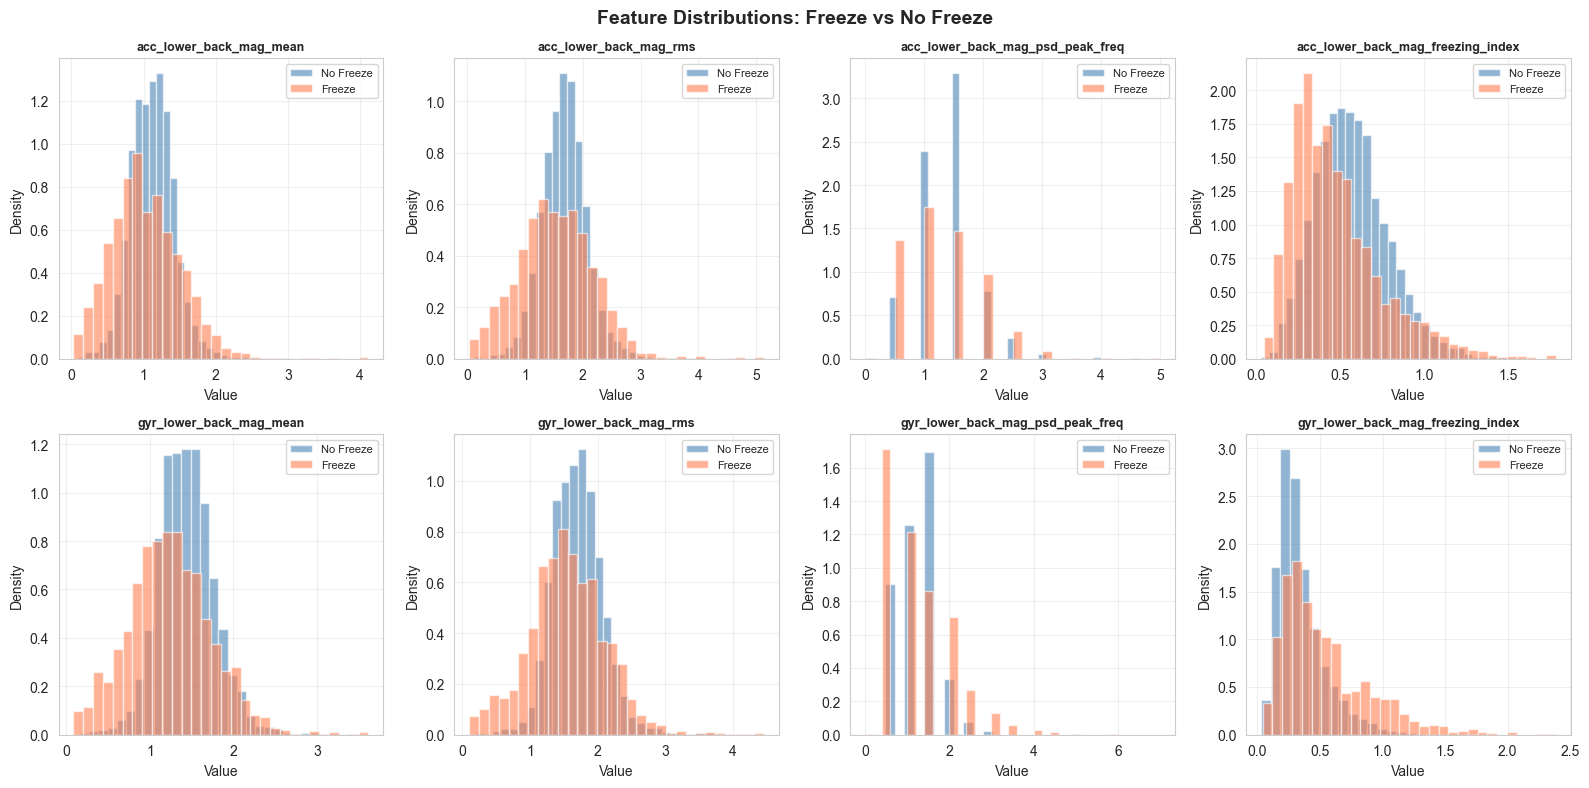

In [ ]:
# Separate by class (replace inf so histograms and Cohen's d are not distorted)
features_no_freeze = X_train_features[y_train == 0].replace([np.inf, -np.inf], np.nan)
features_freeze    = X_train_features[y_train == 1].replace([np.inf, -np.inf], np.nan)

print(f"📊 Class Distribution:")
print(f"   No Freeze: {len(features_no_freeze):,} windows ({len(features_no_freeze)/len(X_train_features)*100:.1f}%)")
print(f"   Freeze: {len(features_freeze):,} windows ({len(features_freeze)/len(X_train_features)*100:.1f}%)")

# Select representative features (per-group magnitudes)
feature_subset = [
    'acc_lower_back_mag_mean', 'acc_lower_back_mag_rms',
    'acc_lower_back_mag_psd_peak_freq', 'acc_lower_back_mag_freezing_index',
    'gyr_lower_back_mag_mean', 'gyr_lower_back_mag_rms',
    'gyr_lower_back_mag_psd_peak_freq', 'gyr_lower_back_mag_freezing_index',
]

# Filter to existing features
feature_subset = [f for f in feature_subset if f in X_train_features.columns]

# Visualize distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, feat in enumerate(feature_subset[:8]):
    axes[i].hist(features_no_freeze[feat].dropna(), bins=30, alpha=0.6, 
                label='No Freeze', color='steelblue', density=True)
    axes[i].hist(features_freeze[feat].dropna(), bins=30, alpha=0.6, 
                label='Freeze', color='coral', density=True)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

# Hide unused subplots
for i in range(len(feature_subset), 8):
    axes[i].axis('off')

plt.suptitle('Feature Distributions: Freeze vs No Freeze', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Importance by Variance

Identify features with highest variance (potentially most discriminative).

📊 Top 15 Features by Variance:
 1. ch5_coeff_variation                 10084395782.80
 2. ch3_coeff_variation                 1668059091.04
 3. ch0_coeff_variation                  35166593.72
 4. ch2_coeff_variation                  32352034.24
 5. ch4_coeff_variation                  14010879.95
 6. ch1_coeff_variation                   5971084.72
 7. acc_lower_back_mag_wavelet_energy_0    756506.35
 8. gyr_lower_back_mag_wavelet_energy_0    694503.10
 9. ch4_wavelet_energy_0                   126294.93
10. ch3_wavelet_energy_0                    98765.26
11. ch2_wavelet_energy_0                    88102.41
12. ch1_wavelet_energy_0                    63220.52
13. ch5_wavelet_energy_0                    51981.55
14. ch0_wavelet_energy_0                    48352.02
15. ch0_wavelet_energy_1                    16823.01


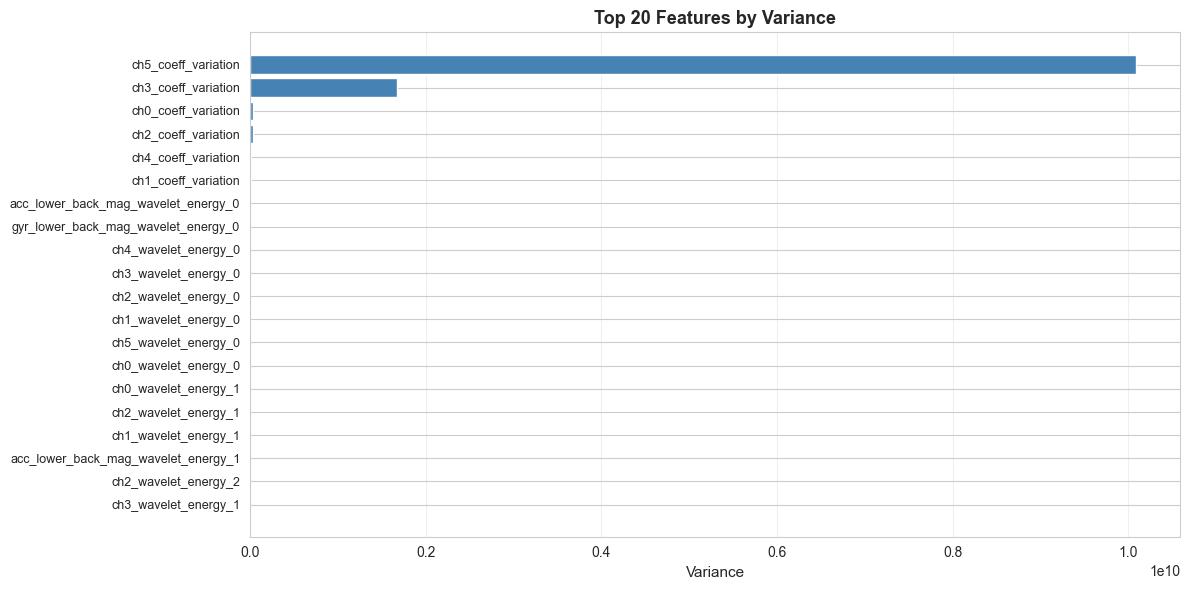

In [ ]:
# Calculate variance for each feature (replace inf with NaN before var to avoid inf results)
feature_variance = (
    X_train_features
    .replace([np.inf, -np.inf], np.nan)
    .var()
    .sort_values(ascending=False)
)

print("📊 Top 15 Features by Variance:")
print("=" * 60)
for i, (feat, var) in enumerate(feature_variance.head(15).items(), 1):
    print(f"{i:2d}. {feat:35s} {var:12.2f}")

# Visualize top features by variance
fig, ax = plt.subplots(figsize=(12, 6))
top_features = feature_variance.dropna().head(20)
ax.barh(range(len(top_features)), top_features.values, color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index, fontsize=9)
ax.set_xlabel('Variance', fontsize=11)
ax.set_title('Top 20 Features by Variance', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Feature Correlation Analysis

Identify highly correlated features (potential redundancy).

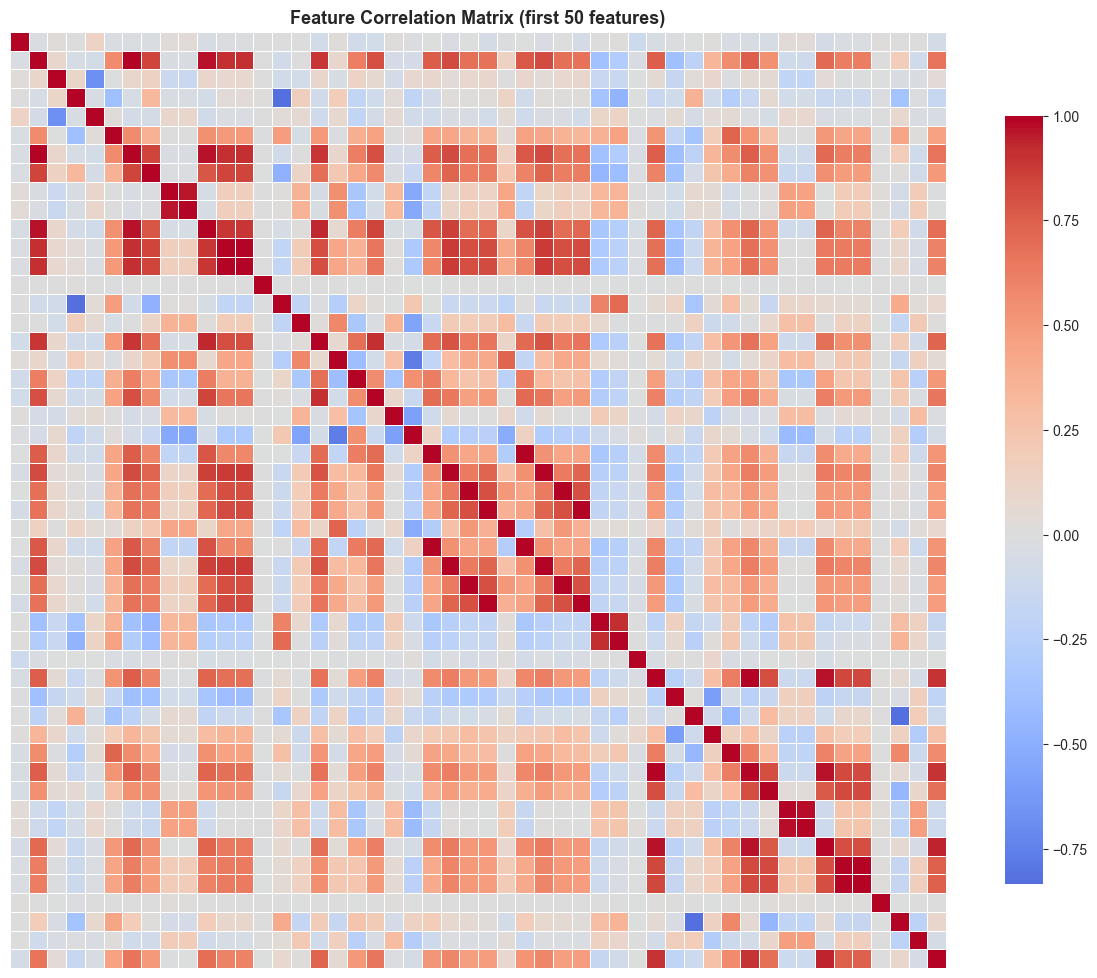


⚠️  Highly correlated pairs (|r| > 0.9): 22

Top 10 correlations:
  ch0_jerk_rms                   <-> ch0_jerk_std                  :  1.000
  ch1_jerk_rms                   <-> ch1_jerk_std                  :  1.000
  ch0_wavelet_energy_2           <-> ch0_wavelet_var_2             :  1.000
  ch0_wavelet_energy_3           <-> ch0_wavelet_var_3             :  1.000
  ch0_std                        <-> ch0_rms                       :  1.000
  ch1_std                        <-> ch1_rms                       :  1.000
  ch0_wavelet_energy_1           <-> ch0_wavelet_var_1             :  1.000
  ch0_wavelet_energy_0           <-> ch0_wavelet_var_0             :  0.999
  ch1_zero_crossing_rate         <-> ch1_mean_crossing_rate        :  0.978
  ch0_rms                        <-> ch0_energy                    :  0.968


In [ ]:
# Compute correlation matrix (replace inf with NaN before corr to avoid propagation)
n_features_viz = min(50, X_train_features.shape[1])
features_sample = (
    X_train_features
    .replace([np.inf, -np.inf], np.nan)
    .iloc[:, :n_features_viz]
)
corr_matrix = features_sample.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
           square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
           xticklabels=False, yticklabels=False)
ax.set_title(f'Feature Correlation Matrix (first {n_features_viz} features)', 
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Find highly correlated pairs
high_corr_threshold = 0.9
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if np.isfinite(val) and abs(val) > high_corr_threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                val
            ))

print(f"\n⚠️  Highly correlated pairs (|r| > {high_corr_threshold}): {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print("\nTop 10 correlations:")
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
        print(f"  {feat1:30s} <-> {feat2:30s}: {corr:6.3f}")

## 9. Class Separability Analysis

Measure how well features separate Freeze from No Freeze using effect size (Cohen's d).

📊 Top 15 Features by Effect Size (Cohen's d):
   Higher effect size = better class separability
   d > 0.8: Large effect
   d > 0.5: Medium effect
   d > 0.2: Small effect
 1. ch5_zero_crossing_rate              d=1.529  (Large)
 2. ch5_mean_crossing_rate              d=1.509  (Large)
 3. ch5_locomotion_band_index           d=1.320  (Large)
 4. ch5_spectral_centroid               d=1.057  (Large)
 5. ch5_freezing_index                  d=0.969  (Large)
 6. ch5_kurt                            d=0.945  (Large)
 7. ch0_freezing_index                  d=0.930  (Large)
 8. gyr_lower_back_mag_entropy          d=0.926  (Large)
 9. gyr_lower_back_mag_skew             d=0.914  (Large)
10. ch5_sample_entropy                  d=0.900  (Large)
11. ch5_entropy                         d=0.900  (Large)
12. ch5_wavelet_entropy                 d=0.888  (Large)
13. ch5_iqr                             d=0.875  (Large)
14. gyr_lower_back_mag_kurt             d=0.873  (Large)
15. gyr_lower_back_mag_coeff_v

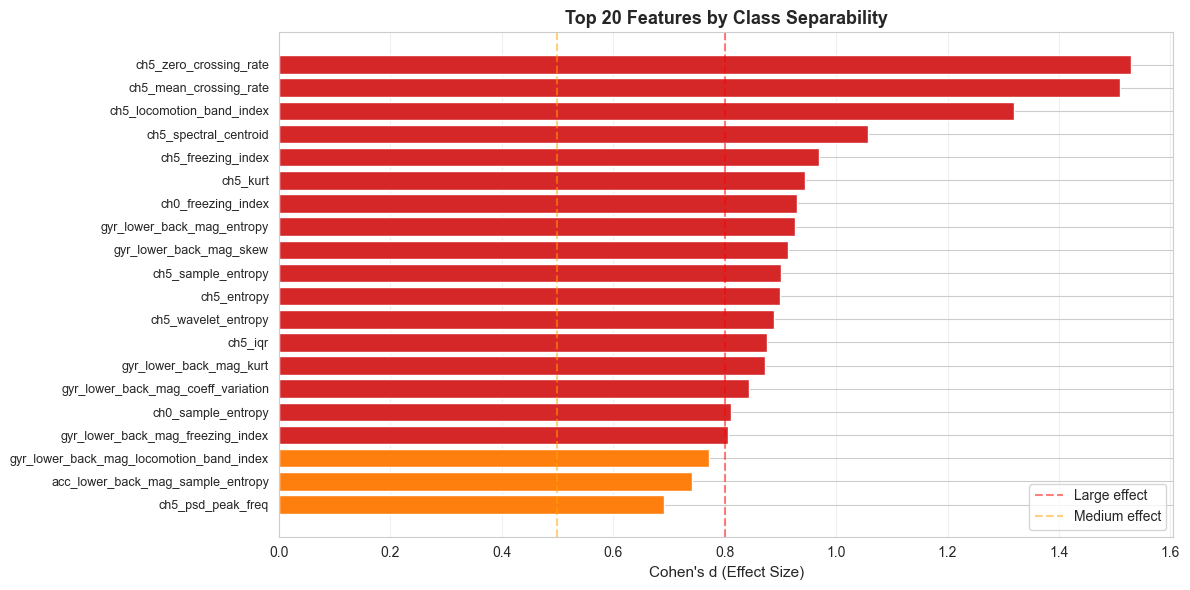

In [ ]:
# Calculate Cohen's d for each feature
def cohens_d(group1, group2):
    """Calculate Cohen's d effect size."""
    mean1, mean2 = group1.mean(), group2.mean()
    std1, std2 = group1.std(), group2.std()
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1+n2-2))
    return abs((mean1 - mean2) / pooled_std) if pooled_std > 0 else 0

effect_sizes = {}
for col in X_train_features.columns:
    d = cohens_d(features_no_freeze[col].dropna(), features_freeze[col].dropna())
    effect_sizes[col] = d

effect_sizes = pd.Series(effect_sizes).sort_values(ascending=False)

print("📊 Top 15 Features by Effect Size (Cohen's d):")
print("=" * 70)
print("   Higher effect size = better class separability")
print("   d > 0.8: Large effect")
print("   d > 0.5: Medium effect")
print("   d > 0.2: Small effect")
print("=" * 70)
for i, (feat, d) in enumerate(effect_sizes.head(15).items(), 1):
    magnitude = "Large" if d > 0.8 else "Medium" if d > 0.5 else "Small" if d > 0.2 else "Negligible"
    print(f"{i:2d}. {feat:35s} d={d:5.3f}  ({magnitude})")

# Visualize top features by effect size
fig, ax = plt.subplots(figsize=(12, 6))
top_effects = effect_sizes.head(20)
colors = ['#d62728' if d > 0.8 else '#ff7f0e' if d > 0.5 else '#2ca02c' for d in top_effects.values]
ax.barh(range(len(top_effects)), top_effects.values, color=colors)
ax.set_yticks(range(len(top_effects)))
ax.set_yticklabels(top_effects.index, fontsize=9)
ax.set_xlabel("Cohen's d (Effect Size)", fontsize=11)
ax.set_title('Top 20 Features by Class Separability', fontsize=13, fontweight='bold')
ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='Large effect')
ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Medium effect')
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Summary

In [ ]:
# Summary statistics
total_train = TOTAL_TRAIN_WINDOWS
total_test = TOTAL_TEST_WINDOWS
expected_fold_dirs = {f"fold_subj_{fold['test_subject']}" for fold in loso_splits}
existing_fold_dirs = {path.name for path in feature_output_dir.glob('fold_subj_*') if path.is_dir()}
missing_fold_dirs = sorted(expected_fold_dirs - existing_fold_dirs)

print('=' * 70)
print('FEATURE EXTRACTION SUMMARY')
print('=' * 70)

print(f'\n📊 Feature Configuration:')
print(f'   Time-domain: ✅ Enabled')
print(f'   Frequency-domain: ✅ Enabled')
print(f'   Wavelet: ✅ Enabled')
print(f'   Nonlinear: ✅ Enabled')

print(f'\n📈 Processing Statistics:')
print(f'   LOSO folds: {len(loso_splits)}')
print(f'   Total train windows: {total_train:,}')
print(f'   Total test windows: {total_test:,}')
print(f'   Features per window: {X_train_features.shape[1]}')

print(f'\n🧪 Signal Preparation:')
if FIGSHARE_NOTEBOOK03_MODE == 'full_pickle':
    print('   Source windows: raw outputs from notebook 02')
else:
    print('   Source windows: existing feature CSVs on disk (pickle load skipped due to MemoryError)')
print('   Outlier cleaning: disabled')
print('   Aggressive interpolation: disabled')
print('   Non-finite feature values: sanitized to NaN by FeatureExtractor')
print('   Downstream handling: notebook 04 imputes missing values during training')

print(f'\n💾 Output:')
print(f'   Directory: {feature_output_dir}')
print('   Files per fold: X_train_features.csv, y_train.csv, subjects_train.csv, X_test_features.csv, y_test.csv')
print(f'   Existing fold directories: {len(existing_fold_dirs)}')
if missing_fold_dirs:
    print(f'   Missing fold directories: {len(missing_fold_dirs)}')
    for name in missing_fold_dirs[:10]:
        print(f'     - {name}')
    if len(missing_fold_dirs) > 10:
        print(f'     ... and {len(missing_fold_dirs) - 10} more')
else:
    print('   Output integrity: all expected fold directories are present')

print(f'\n🎯 Key Insights:')
print(f'   Top feature (variance): {feature_variance.index[0]}')
print(f'   Top feature (effect size): {effect_sizes.index[0]} (d={effect_sizes.iloc[0]:.3f})')
print(f'   Highly correlated pairs: {len(high_corr_pairs)}')

print('\n' + '=' * 70)
print('✅ Dataset ready for training!')
print('📌 Next step: Run notebook 04_loso_pipeline_and_training.ipynb')
print('=' * 70)

FEATURE EXTRACTION SUMMARY

📊 Feature Configuration:
   Time-domain: ✅ Enabled
   Frequency-domain: ✅ Enabled
   Wavelet: ✅ Enabled
   Nonlinear: ✅ Enabled

📈 Processing Statistics:
   LOSO folds: 35
   Total train windows: 282,438
   Total test windows: 2,130
   Features per window: 264

🧪 Signal Preparation:
   Source windows: raw outputs from notebook 02
   Outlier cleaning: disabled
   Aggressive interpolation: disabled
   Non-finite feature values: sanitized to NaN by FeatureExtractor
   Downstream handling: notebook 04 imputes missing values during training

💾 Output:
   Directory: ..\..\outputs\figshare_features
   Files per fold: X_train_features.csv, y_train.csv, subjects_train.csv, X_test_features.csv, y_test.csv
   Existing fold directories: 35
   Output integrity: all expected fold directories are present

🎯 Key Insights:
   Top feature (variance): ch5_coeff_variation
   Top feature (effect size): ch5_zero_crossing_rate (d=1.529)
   Highly correlated pairs: 22

✅ Dataset re

## 11. Raw Model Training for Preprocessing Experiments

This section adds a **fast LOSO baseline** to evaluate preprocessing choices directly from the extracted feature CSVs.

**Design goals:**
- no hyperparameter tuning
- no feature selection
- fixed, simple models
- configurable preprocessing steps so you can compare variants quickly
- optional class balancing with `SMOTE` to test whether `F1` improves or degrades
- configurable imputation, including `KNNImputer`, to test whether feature-space missing-value handling helps

Edit the configuration cell below to experiment with imputation, scaling, and class balancing.

In [ ]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix
)
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

PREPROCESSING_EXPERIMENT_NAME = 'baseline_curated_features_robust'
PREPROCESSING_CONFIG = {
    'replace_inf_with_nan': True,
    'imputer_strategy': 'median',  # options: knn, median, mean, most_frequent, none
    'knn_imputer_neighbors': 5,
    'scaler': 'robust',            # options: standard, robust, none
    'resampler': 'none',           # options: none, random_oversampler, smote, adasyn
    'resampler_k_neighbors': 5,
}

RAW_BASELINE_MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=1,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=300,
        early_stopping=True,
        random_state=42
    ),
}

def clean_raw_features(df, replace_inf_with_nan=True):
    X = df.copy()
    if replace_inf_with_nan:
        X = X.replace([np.inf, -np.inf], np.nan)
    return X

def build_raw_baseline_pipeline(model, config, y_train=None):
    steps = []

    if config['imputer_strategy'] == 'knn':
        steps.append(('imputer', KNNImputer(n_neighbors=config['knn_imputer_neighbors'])))
    elif config['imputer_strategy'] != 'none':
        steps.append(('imputer', SimpleImputer(strategy=config['imputer_strategy'])))

    if config['scaler'] == 'standard':
        steps.append(('scaler', StandardScaler()))
    elif config['scaler'] == 'robust':
        steps.append(('scaler', RobustScaler()))

    if config['resampler'] == 'random_oversampler':
        steps.append(('ros', RandomOverSampler(random_state=42)))
    elif config['resampler'] in ('smote', 'adasyn'):
        if y_train is None:
            raise ValueError('y_train is required when using SMOTE or ADASYN')
        minority_count = int(pd.Series(y_train).value_counts().min())
        if minority_count >= 2:
            k_neighbors = min(config['resampler_k_neighbors'], minority_count - 1)
            if config['resampler'] == 'smote':
                steps.append(('smote', SMOTE(random_state=42, k_neighbors=k_neighbors)))
            else:
                steps.append(('adasyn', ADASYN(random_state=42, n_neighbors=k_neighbors)))
        else:
            print('  ⚠️ Resampler skipped: not enough minority samples in training fold.')

    steps.append(('classifier', model))
    return ImbPipeline(steps)

print('Raw baseline training config:')
print(f"  Experiment name: {PREPROCESSING_EXPERIMENT_NAME}")
for key, value in PREPROCESSING_CONFIG.items():
    print(f"  - {key}: {value}")
print('Models:', ', '.join(RAW_BASELINE_MODELS.keys()))

In [ ]:
from pathlib import Path
import json

fold_dirs = sorted([p for p in feature_output_dir.glob('fold_subj_*') if p.is_dir()])
results_output_dir = feature_output_dir.parent / 'figshare_results'
results_output_dir.mkdir(parents=True, exist_ok=True)

print(f'Found {len(fold_dirs)} fold directories in {feature_output_dir}')

raw_baseline_rows = []
raw_baseline_predictions = []

for fold_dir in fold_dirs:
    subject_id = fold_dir.name.replace('fold_subj_', '')

    X_train = pd.read_csv(fold_dir / 'X_train_features.csv')
    X_test = pd.read_csv(fold_dir / 'X_test_features.csv')
    y_train = pd.read_csv(fold_dir / 'y_train.csv').squeeze('columns')
    y_test = pd.read_csv(fold_dir / 'y_test.csv').squeeze('columns')

    X_train = clean_raw_features(
        X_train,
        replace_inf_with_nan=PREPROCESSING_CONFIG['replace_inf_with_nan']
    )
    X_test = clean_raw_features(
        X_test,
        replace_inf_with_nan=PREPROCESSING_CONFIG['replace_inf_with_nan']
    )

    print(f'\n=== Fold {subject_id} ===')
    print(f'Train shape: {X_train.shape} | Test shape: {X_test.shape}')
    print(f'Train class distribution: {dict(pd.Series(y_train).value_counts().sort_index())}')
    print(f'Test class distribution: {dict(pd.Series(y_test).value_counts().sort_index())}')

    for model_name, model in RAW_BASELINE_MODELS.items():
        pipeline = build_raw_baseline_pipeline(model, PREPROCESSING_CONFIG, y_train=y_train)
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

        metrics_row = {
            'subject_id': subject_id,
            'model': model_name,
            'n_train': len(X_train),
            'n_test': len(X_test),
            'n_features': X_train.shape[1],
            'accuracy': accuracy_score(y_test, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'tn': int(tn),
            'fp': int(fp),
            'fn': int(fn),
            'tp': int(tp),
            'resampler': PREPROCESSING_CONFIG['resampler'],
        }
        raw_baseline_rows.append(metrics_row)

        fold_predictions = pd.DataFrame({
            'subject_id': subject_id,
            'model': model_name,
            'y_true': y_test.to_numpy(),
            'y_pred': y_pred,
            'resampler': PREPROCESSING_CONFIG['resampler'],
        })
        raw_baseline_predictions.append(fold_predictions)

raw_baseline_results = pd.DataFrame(raw_baseline_rows)
raw_baseline_summary = (
    raw_baseline_results
    .groupby('model')[['accuracy', 'balanced_accuracy', 'precision', 'recall', 'f1']]
    .agg(['mean', 'std'])
    .round(4)
    .sort_values(('f1', 'mean'), ascending=False)
)

predictions_df = pd.concat(raw_baseline_predictions, ignore_index=True)

results_path = results_output_dir / f'{PREPROCESSING_EXPERIMENT_NAME}_raw_model_results.csv'
summary_path = results_output_dir / f'{PREPROCESSING_EXPERIMENT_NAME}_raw_model_summary.csv'
predictions_path = results_output_dir / f'{PREPROCESSING_EXPERIMENT_NAME}_raw_model_predictions.csv'
config_path = results_output_dir / f'{PREPROCESSING_EXPERIMENT_NAME}_raw_model_config.json'

raw_baseline_results.to_csv(results_path, index=False)
raw_baseline_summary.to_csv(summary_path)
predictions_df.to_csv(predictions_path, index=False)

config_payload = {
    'experiment_name': PREPROCESSING_EXPERIMENT_NAME,
    'preprocessing_config': PREPROCESSING_CONFIG,
    'models': list(RAW_BASELINE_MODELS.keys()),
    'n_folds': len(fold_dirs),
}
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config_payload, f, indent=2)

display(raw_baseline_results.head())
display(raw_baseline_summary)

print(f'\nSaved fold-level results to: {results_path}')
print(f'Saved summary to: {summary_path}')
print(f'Saved predictions to: {predictions_path}')
print(f'Saved config to: {config_path}')

## 12. Lightweight LOSO Training for Quick Validation

This section adds a **light Notebook 04-style training pass** directly inside notebook 03 so it can be tested quickly after feature extraction.

**What it includes:**
- train-only preprocessing in each LOSO fold
- per-subject robust normalization in feature space
- removal of constant features using the training split only
- lightweight `SelectKBest` feature selection
- median imputation + robust scaling + random oversampling
- threshold tuning from out-of-fold training predictions with `GroupKFold`

**Design goal:**
- faster than the full notebook 04 pipeline
- subject-aware and reasonably leakage-safe
- good enough for rapid iteration before running the heavier experiments

In [ ]:
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.base import clone
from sklearn.metrics import precision_recall_curve

LIGHT_TRAINING_EXPERIMENT_NAME = 'lightweight_loso_curated_thresholded'
LIGHT_TRAINING_CONFIG = {
    'replace_inf_with_nan': True,
    'k_best': 36,
    'scaler': 'robust',
    'resampler': 'random_oversampler',
    'max_inner_splits': 4,
    'threshold_clip': (0.35, 0.65),
}

LIGHT_TRAINING_MODELS = {
    'Logistic Regression': LogisticRegression(
        C=1.0,
        solver='liblinear',
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=250,
        max_depth=12,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
}

def per_subject_robust_normalize(X, groups):
    X_norm = X.copy()
    groups = pd.Series(groups).astype(str).reset_index(drop=True)
    X_norm = X_norm.reset_index(drop=True)

    for subject in groups.unique():
        mask = groups == subject
        block = X_norm.loc[mask].copy()
        median = block.median(axis=0)
        iqr = block.quantile(0.75, axis=0) - block.quantile(0.25, axis=0)
        iqr = iqr.replace(0, 1.0).fillna(1.0)
        X_norm.loc[mask] = (block - median) / iqr

    return X_norm

def prepare_fold_feature_matrices(X_train, X_test, subjects_train, subject_id, replace_inf_with_nan=True):
    X_train = clean_raw_features(X_train, replace_inf_with_nan=replace_inf_with_nan)
    X_test = clean_raw_features(X_test, replace_inf_with_nan=replace_inf_with_nan)

    train_groups = pd.Series(subjects_train).astype(str).reset_index(drop=True)
    test_groups = pd.Series([str(subject_id)] * len(X_test))

    X_train = per_subject_robust_normalize(X_train, train_groups)
    X_test = per_subject_robust_normalize(X_test, test_groups)

    non_constant_cols = X_train.columns[X_train.nunique(dropna=False) > 1].tolist()
    if not non_constant_cols:
        non_constant_cols = X_train.columns.tolist()

    return (
        X_train[non_constant_cols].copy(),
        X_test[non_constant_cols].copy(),
        train_groups,
        non_constant_cols,
    )

def build_light_training_pipeline(model, config, n_features):
    k_best = max(1, min(config['k_best'], n_features))
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('selector', SelectKBest(score_func=f_classif, k=k_best)),
    ]

    if config['scaler'] == 'robust':
        steps.append(('scaler', RobustScaler()))

    if config['resampler'] == 'random_oversampler':
        steps.append(('ros', RandomOverSampler(random_state=42)))

    steps.append(('classifier', clone(model)))
    return ImbPipeline(steps)

def tune_binary_threshold(pipeline, X_train, y_train, groups, n_splits, threshold_clip=(0.35, 0.65)):
    if n_splits < 2 or pd.Series(y_train).nunique() < 2:
        return 0.5

    y_score_oof = cross_val_predict(
        pipeline,
        X_train,
        y_train,
        groups=groups,
        cv=GroupKFold(n_splits=n_splits),
        method='predict_proba',
        n_jobs=1,
    )[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_train, y_score_oof)
    if len(thresholds) == 0:
        return 0.5

    f1_values = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
    best_idx = int(np.argmax(f1_values))
    low, high = threshold_clip
    return float(np.clip(thresholds[best_idx], low, high))

print('Lightweight LOSO training config:')
print(f"  Experiment name: {LIGHT_TRAINING_EXPERIMENT_NAME}")
for key, value in LIGHT_TRAINING_CONFIG.items():
    print(f"  - {key}: {value}")
print('Models:', ', '.join(LIGHT_TRAINING_MODELS.keys()))

In [ ]:
light_rows = []
light_prediction_frames = []

for fold_dir in fold_dirs:
    subject_id = fold_dir.name.replace('fold_subj_', '')

    X_train = pd.read_csv(fold_dir / 'X_train_features.csv')
    X_test = pd.read_csv(fold_dir / 'X_test_features.csv')
    y_train = pd.read_csv(fold_dir / 'y_train.csv').squeeze('columns')
    y_test = pd.read_csv(fold_dir / 'y_test.csv').squeeze('columns')
    subjects_train = pd.read_csv(fold_dir / 'subjects_train.csv').squeeze('columns')

    X_train_prep, X_test_prep, train_groups, kept_cols = prepare_fold_feature_matrices(
        X_train,
        X_test,
        subjects_train,
        subject_id,
        replace_inf_with_nan=LIGHT_TRAINING_CONFIG['replace_inf_with_nan'],
    )

    unique_groups = train_groups.nunique()
    inner_splits = min(LIGHT_TRAINING_CONFIG['max_inner_splits'], unique_groups)

    print(f"\n=== Lightweight LOSO Fold {subject_id} ===")
    print(f"Train shape after prep: {X_train_prep.shape} | Test shape after prep: {X_test_prep.shape}")
    print(f"Unique train subjects for threshold tuning: {unique_groups}")

    if pd.Series(y_train).nunique() < 2:
        print('  ⚠️ Skipping fold: training split is monoclase.')
        continue

    for model_name, base_model in LIGHT_TRAINING_MODELS.items():
        print(f"  -> Training {model_name} ...")

        pipeline = build_light_training_pipeline(
            base_model,
            LIGHT_TRAINING_CONFIG,
            n_features=X_train_prep.shape[1],
        )

        threshold = tune_binary_threshold(
            pipeline,
            X_train_prep,
            y_train,
            train_groups,
            n_splits=inner_splits,
            threshold_clip=LIGHT_TRAINING_CONFIG['threshold_clip'],
        )

        pipeline.fit(X_train_prep, y_train)
        y_score = pipeline.predict_proba(X_test_prep)[:, 1]
        y_pred = (y_score >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
        selected_count = int(pipeline.named_steps['selector'].get_support().sum())

        light_rows.append({
            'subject_id': subject_id,
            'model': model_name,
            'threshold': threshold,
            'accuracy': accuracy_score(y_test, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'tn': int(tn),
            'fp': int(fp),
            'fn': int(fn),
            'tp': int(tp),
            'n_train': len(X_train_prep),
            'n_test': len(X_test_prep),
            'n_features_before_select': X_train_prep.shape[1],
            'n_features_selected': selected_count,
            'inner_cv_splits': inner_splits,
        })

        light_prediction_frames.append(pd.DataFrame({
            'subject_id': subject_id,
            'model': model_name,
            'y_true': y_test.to_numpy(),
            'y_score': y_score,
            'y_pred': y_pred,
            'threshold': threshold,
        }))

light_results_df = pd.DataFrame(light_rows)
light_predictions_df = pd.concat(light_prediction_frames, ignore_index=True) if light_prediction_frames else pd.DataFrame()

light_summary_df = (
    light_results_df
    .groupby('model')[['accuracy', 'balanced_accuracy', 'precision', 'recall', 'f1', 'threshold', 'n_features_selected']]
    .agg(['mean', 'std'])
    .round(4)
    .sort_values(('f1', 'mean'), ascending=False)
    if not light_results_df.empty else pd.DataFrame()
)

light_results_path = results_output_dir / f'{LIGHT_TRAINING_EXPERIMENT_NAME}_results.csv'
light_summary_path = results_output_dir / f'{LIGHT_TRAINING_EXPERIMENT_NAME}_summary.csv'
light_predictions_path = results_output_dir / f'{LIGHT_TRAINING_EXPERIMENT_NAME}_predictions.csv'
light_config_path = results_output_dir / f'{LIGHT_TRAINING_EXPERIMENT_NAME}_config.json'

light_results_df.to_csv(light_results_path, index=False)
light_summary_df.to_csv(light_summary_path)
light_predictions_df.to_csv(light_predictions_path, index=False)

with open(light_config_path, 'w', encoding='utf-8') as f:
    json.dump({
        'experiment_name': LIGHT_TRAINING_EXPERIMENT_NAME,
        'config': LIGHT_TRAINING_CONFIG,
        'models': list(LIGHT_TRAINING_MODELS.keys()),
        'n_folds_evaluated': int(light_results_df['subject_id'].nunique()) if not light_results_df.empty else 0,
    }, f, indent=2)

display(light_results_df.head())
display(light_summary_df)

print(f'\nSaved lightweight fold-level results to: {light_results_path}')
print(f'Saved lightweight summary to: {light_summary_path}')
print(f'Saved lightweight predictions to: {light_predictions_path}')
print(f'Saved lightweight config to: {light_config_path}')